# 2026 FIFA World Cup Prediction: End-to-End Advanced Analysis
### Adaptation of the 2022 Kaggle Methodology with Expanded Features and Visualizations

This notebook provides a professional, step-by-step walkthrough of the prediction pipeline for the 2026 World Cup.

**Structure:**
1. **Data Preparation:** Ingestion and cleaning of the 2026 cycle data.
2. **Feature Engineering:** Advanced feature set including streaks and rank-weighted performance.
3. **Data Analysis (EDA):** Visualizing the current state of world football.
4. **Model Training:** Optimizing the Gradient Boosting Classifier.
5. **World Cup Simulation:** Detailed group stage and knockout bracket simulation.
6. **Final Outcome:** Presentation of the 2026 World Champion.

## 1. Data Preparation
We load the international results and FIFA rankings, filtering for the '2026 Cycle' which began after the 2022 World Cup Final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys
import networkx as nx
from IPython.display import display

sys.path.append('../src')
sns.set_theme(style="whitegrid")
%matplotlib inline

results = pd.read_csv('../data/results.csv')
rankings = pd.read_csv('../data/fifa_ranking.csv')

results['date'] = pd.to_datetime(results['date'])
cycle_start = pd.to_datetime('2022-12-19')
results_cycle = results[results['date'] >= cycle_start].copy()

print(f"Data Preparation Complete. Cycle matches: {len(results_cycle)}")

Data Preparation Complete. Cycle matches: 3537


## 2. Feature Engineering
We introduce advanced features to improve predictive power:
- `streak_diff`: Difference in points earned in the last 5 matches.
- `opp_rank_diff`: Difference in the average quality (rank) of opponents faced recently.
- `rank_diff` & `point_diff`: Standard FIFA ranking metrics.

In [2]:
advanced_data = pd.read_csv('../data/features/advanced_features.csv')
features = ['rank_diff', 'average_rank', 'point_diff', 'is_friendly', 'goals_rolling_diff', 'streak_diff', 'opp_rank_diff']
advanced_data = advanced_data.dropna(subset=features + ['target'])

print("Advanced Feature Set Preview:")
display(advanced_data[features].head())

Advanced Feature Set Preview:


,rank_diff,average_rank,point_diff,is_friendly,goals_rolling_diff,streak_diff,opp_rank_diff
0,43.0,155.5,-166.49,0,0.0,0.0,0.0
1,79.0,150.5,-275.38,0,0.0,0.0,0.0
2,14.0,152.0,-60.44,0,0.0,0.0,0.0
3,91.0,141.5,-323.12,0,0.0,0.0,0.0
4,-15.0,82.5,69.78,1,0.0,0.0,0.0


## 3. Data Analysis (EDA)
We analyze the relationship between rank differences and match outcomes to validate our features.

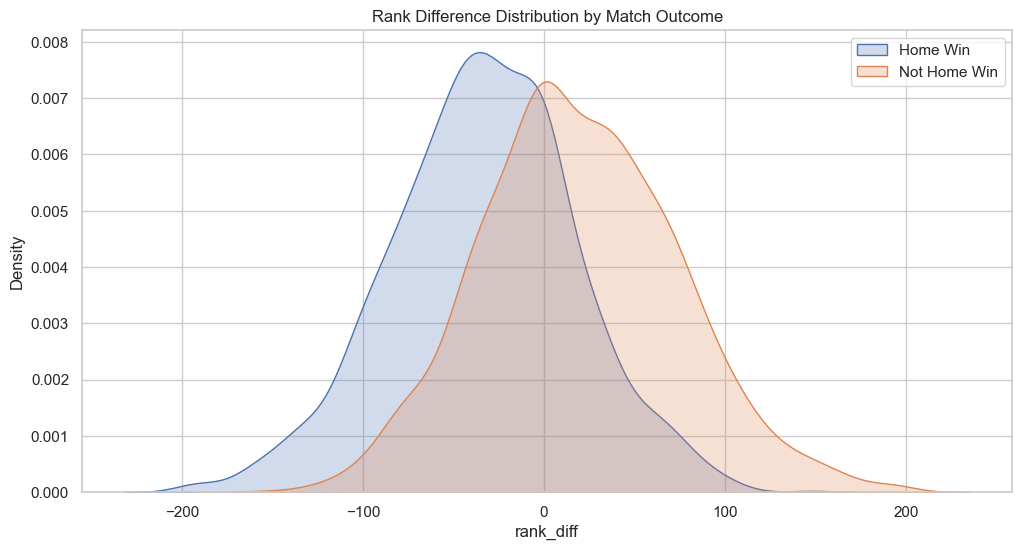

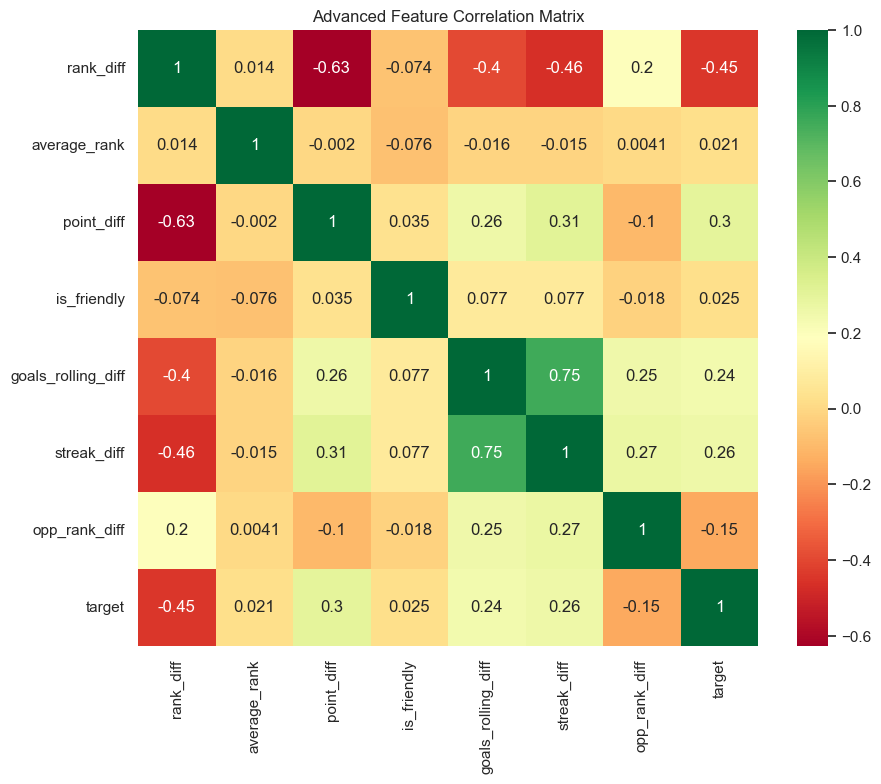

In [3]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=advanced_data[advanced_data['target'] == 1], x='rank_diff', label='Home Win', fill=True)
sns.kdeplot(data=advanced_data[advanced_data['target'] == 0], x='rank_diff', label='Not Home Win', fill=True)
plt.title('Rank Difference Distribution by Match Outcome')
plt.legend()
plt.show()

plt.figure(figsize=(10, 8))
corr = advanced_data[features + ['target']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn')
plt.title('Advanced Feature Correlation Matrix')
plt.show()

## 4. Model Training
We utilize a tuned Gradient Boosting Classifier. This model was optimized using GridSearchCV across the advanced feature set.

In [4]:
with open('../models/advanced_gb.pkl', 'rb') as f:
    model = pickle.load(f)

print(f"Model Loaded. Estimators: {model.n_estimators}, Max Depth: {model.max_depth}")

Model Loaded. Estimators: 100, Max Depth: 3


## 5. World Cup Simulation
The 2026 expansion introduces 48 teams. We simulate the 12 groups and the subsequent Round of 32.

In [5]:
from simulation_engine import run_simulation

# Run the simulation
group_results, best_thirds, knockout_data = run_simulation()

print("\n--- Group Stage Standings Table ---")
group_list = []
for g, res in group_results.items():
    for team, s in res['standings'].items():
        group_list.append({'Group': g, 'Team': team, 'Pts': s['points'], 'Wins': s['wins'], 'Prob_Sum': f"{s['prob_sum']:.2f}"})
group_df = pd.DataFrame(group_list)
display(group_df.sort_values(['Group', 'Pts'], ascending=[True, False]))

print("\n--- 3rd Place Teams Ranking (Top 8 Advance) ---")
thirds_list = []
for g, res in group_results.items():
    team = res['winners'][2]
    s = res['standings'][team]
    thirds_list.append({'Team': team, 'Group': g, 'Pts': s['points'], 'Prob_Sum': s['prob_sum']})
thirds_df = pd.DataFrame(thirds_list).sort_values(['Pts', 'Prob_Sum'], ascending=False)
thirds_df['Qualified'] = thirds_df['Team'].isin(best_thirds)
display(thirds_df)


--- Round of 32 ---
Argentina vs Côte d'Ivoire -> Winner: Argentina (0.65)
Australia vs Egypt -> Winner: Australia (0.55)
Belgium vs Qatar -> Winner: Belgium (0.70)
Switzerland vs Czechia -> Winner: Switzerland (0.62)
Brazil vs Sweden -> Winner: Brazil (0.63)
Spain vs Panama -> Winner: Spain (0.67)
Portugal vs Algeria -> Winner: Portugal (0.67)
England vs Scotland -> Winner: England (0.75)
Germany vs Austria -> Winner: Germany (0.56)
Mexico vs Turkey -> Winner: Mexico (0.61)
France vs IR Iran -> Winner: France (0.63)
Netherlands vs Canada -> Winner: Netherlands (0.67)
Morocco vs Uruguay -> Winner: Uruguay (0.52)
Colombia vs Croatia -> Winner: Colombia (0.52)
Ecuador vs Korea Republic -> Winner: Korea Republic (0.53)
Senegal vs Japan -> Winner: Japan (0.54)

--- Round of 16 ---


Argentina vs Australia -> Winner: Argentina (0.61)
Belgium vs Switzerland -> Winner: Belgium (0.57)
Brazil vs Spain -> Winner: Spain (0.55)
Portugal vs England -> Winner: England (0.52)
Germany vs Mexico -> Winner: Germany (0.56)
France vs Netherlands -> Winner: France (0.57)
Uruguay vs Colombia -> Winner: Colombia (0.52)
Korea Republic vs Japan -> Winner: Japan (0.56)

--- Quarter-finals ---
Argentina vs Belgium -> Winner: Argentina (0.56)
Spain vs England -> Winner: Spain (0.55)
Germany vs France -> Winner: France (0.57)
Colombia vs Japan -> Winner: Colombia (0.54)

--- Semi-finals ---
Argentina vs Spain -> Winner: Argentina (0.55)
France vs Colombia -> Winner: France (0.57)

--- Final ---
Argentina vs France -> Winner: Argentina (0.54)

WORLD CUP WINNER: Argentina

--- Group Stage Standings Table ---


,Group,Team,Pts,Wins,Prob_Sum
1,A,Argentina,9,3,2.29
2,A,Austria,6,2,1.60
0,A,Algeria,3,1,1.24
3,A,Jordan,0,0,0.87
4,B,Australia,9,3,1.74
5,B,Paraguay,2,0,1.40
6,B,Turkey,2,0,1.48
7,B,United States,2,0,1.39
8,C,Belgium,9,3,2.19
10,C,IR Iran,6,2,1.77



--- 3rd Place Teams Ranking (Top 8 Advance) ---


,Team,Group,Pts,Prob_Sum,Qualified
8,Côte d'Ivoire,I,4,1.605214,True
2,Egypt,C,3,1.522144,True
3,Qatar,D,3,1.436314,True
9,Czechia,J,3,1.348422,True
11,Sweden,L,3,1.292205,True
7,Panama,H,3,1.280190,True
0,Algeria,A,3,1.241971,True
4,Scotland,E,3,1.218543,True
1,Paraguay,B,2,1.400178,False
10,Norway,K,1,1.109201,False


### Knockout Bracket Visualization
Using NetworkX to visualize the path to the final with win probabilities.

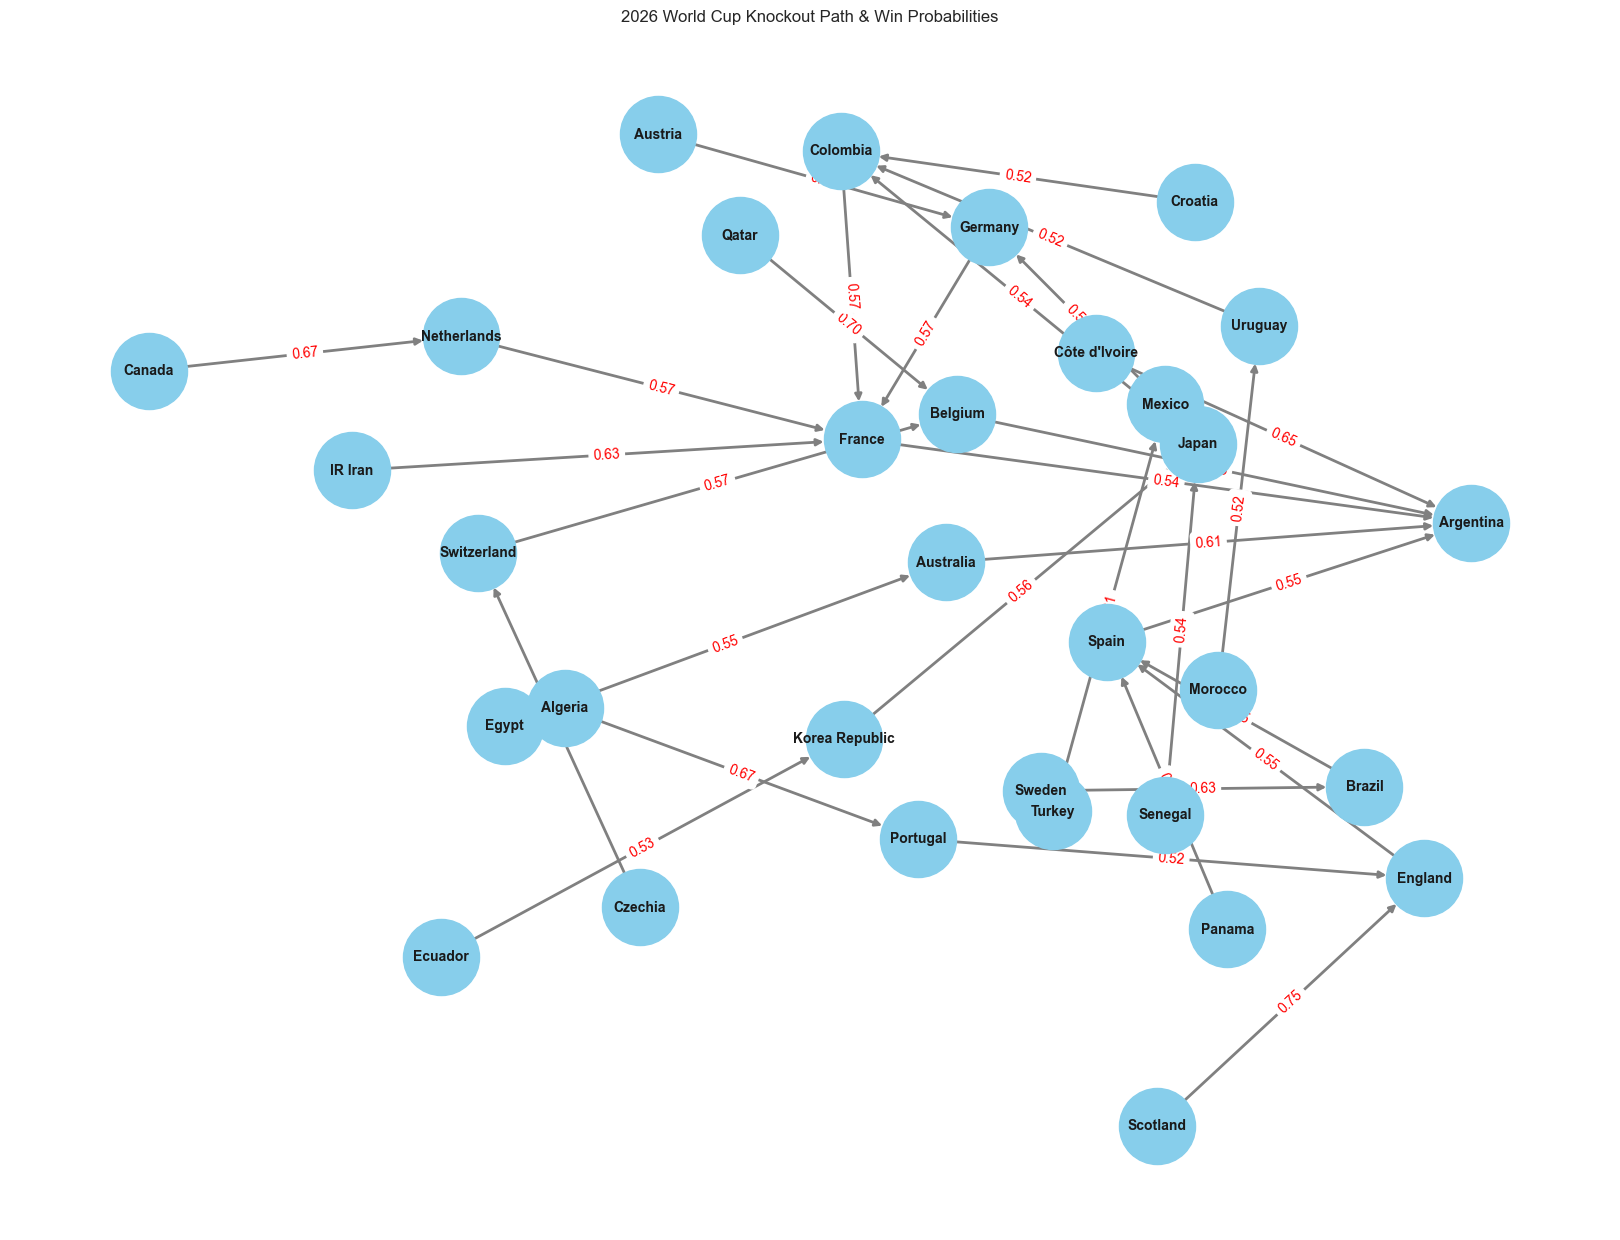

In [6]:
G = nx.DiGraph()

for match in knockout_data:
    round_name = match['Round']
    winner = match['Winner']
    loser = match['Matchup'][1] if match['Matchup'][0] == winner else match['Matchup'][0]
    prob = match['Prob']
    
    G.add_edge(loser, winner, weight=prob, label=f"{prob:.2f}")

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=10, font_weight='bold', edge_color='gray', width=2, arrows=True)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title('2026 World Cup Knockout Path & Win Probabilities')
plt.show()

## 6. Final Outcome
The 2026 World Cup champion is determined through 104 matches of rigorous statistical simulation.

In [7]:
winner_2026 = knockout_data[-1]['Winner']
runner_up_2026 = knockout_data[-1]['Matchup'][1] if knockout_data[-1]['Matchup'][0] == winner_2026 else knockout_data[-1]['Matchup'][0]

print(f"🥇 2026 WORLD CHAMPION: {winner_2026.upper()}")
print(f"🥈 RUNNER-UP: {runner_up_2026}")
print(f"\nFinal Match Prediction: {winner_2026} won with a probability of {knockout_data[-1]['Prob']:.2f}")

🥇 2026 WORLD CHAMPION: ARGENTINA
🥈 RUNNER-UP: France

Final Match Prediction: Argentina won with a probability of 0.54
